




































































































































# Notebook de Optimización: Método de Newton-Raphson

Este cuaderno implementa el método de optimización de Newton-Raphson para encontrar el mínimo de una función diferenciable en una variable. Además, visualiza la función con el punto óptimo encontrado y la convergencia del error a lo largo de las iteraciones.

## ¿Qué es el Método de Newton-Raphson en Optimización?

En optimización unidimensional, los extremos locales de una función `f(x)` se encuentran en puntos donde `f'(x)=0`. El método de Newton-Raphson aplica una iteración de tipo raíz sobre la derivada para aproximar ese punto crítico.

La iteración usada es:

`x_{k+1} = x_k - f'(x_k)/f''(x_k)`

El algoritmo para hallar un mínimo en este cuaderno funciona así:

1. Se elige un valor inicial `x0`.
2. Se calculan `f'(x_k)` y `f''(x_k)` en cada iteración.
3. Se actualiza `x_k` con la fórmula de Newton-Raphson.
4. Se detiene cuando `|x_{k+1} - x_k|` es menor que la tolerancia.
5. Se clasifica el punto encontrado usando el signo de `f''(x_opt)` (positivo para mínimo local).

La convergencia suele ser muy rápida cuando el punto inicial está cerca del óptimo y `f''(x)` no es cercana a cero en el proceso.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import inspect
import sympy as sp



In [6]:
import sympy as sp

X = sp.symbols('x')

f_expr = X**3 - X**2 -10

df_expr = sp.diff(f_expr, X)
ddf_expr = sp.diff(f_expr, X, 2)

In [7]:
f = sp.lambdify(X, f_expr, 'numpy')
df = sp.lambdify(X, df_expr, 'numpy')
ddf = sp.lambdify(X, ddf_expr, 'numpy')

In [8]:
def newton_raphson_minimizacion(func, dfunc, ddfunc, x0, tol=1e-6, max_iter=100):
    xk = float(x0)
    historial_error = []

    for i in range(max_iter):
        dfk = float(dfunc(xk))
        ddfk = float(ddfunc(xk))

        if abs(dfk) < tol:
            break

        if abs(ddfk) < 1e-12:
            step = -np.sign(dfk) * 1e-3
        else:
            step = -dfk / ddfk

        alpha = 1.0
        fxk = func(xk)

        while alpha > 1e-6:
            x_candidate = xk + alpha * step
            if func(x_candidate) < fxk:
                break
            alpha *= 0.5

        x_next = xk + alpha * step

        error = abs(x_next - xk)
        historial_error.append((i + 1, error))

        xk = x_next

        if error < tol:
            break

    return xk, func(xk), historial_error


def newton_raphson_maximizacion(func, dfunc, ddfunc, x0, tol=1e-6, max_iter=100):
    return newton_raphson_minimizacion(
        lambda x: -func(x),
        lambda x: -dfunc(x),
        lambda x: -ddfunc(x),
        x0,
        tol,
        max_iter
    )

In [9]:
x0_inicial = 2.0
tolerancia = 1e-6

print(f"Buscando el mínimo de f(x) = {f_expr}")
print(f"Desde x0 = {x0_inicial}, tolerancia = {tolerancia}\n")

x_min, f_min, historial = newton_raphson_minimizacion(
    f, df, ddf, x0_inicial, tol=tolerancia
)

print(f"Mínimo encontrado en x = {x_min:.6f}")
print(f"Valor de la función = {f_min:.6f}")
print(f"Iteraciones = {len(historial)}")

if historial:
    print(f"Error final = {historial[-1][1]:.6e}")

# Validación
if abs(df(x_min)) > tolerancia:
    print("⚠️ Advertencia: el punto encontrado NO es crítico")

segunda = ddf(x_min)

if abs(df(x_min)) < tolerancia:
    if segunda > 0:
        print("Clasificación: mínimo local.")
    elif segunda < 0:
        print("Clasificación: máximo local.")
    else:
        print("Clasificación: punto de inflexión.")
else:
    print("Clasificación: punto no crítico (resultado inválido).")

Buscando el mínimo de f(x) = x**3 - x**2 - 10
Desde x0 = 2.0, tolerancia = 1e-06

Mínimo encontrado en x = 0.666667
Valor de la función = -10.148148
Iteraciones = 6
Error final = 1.545213e-06
Clasificación: mínimo local.


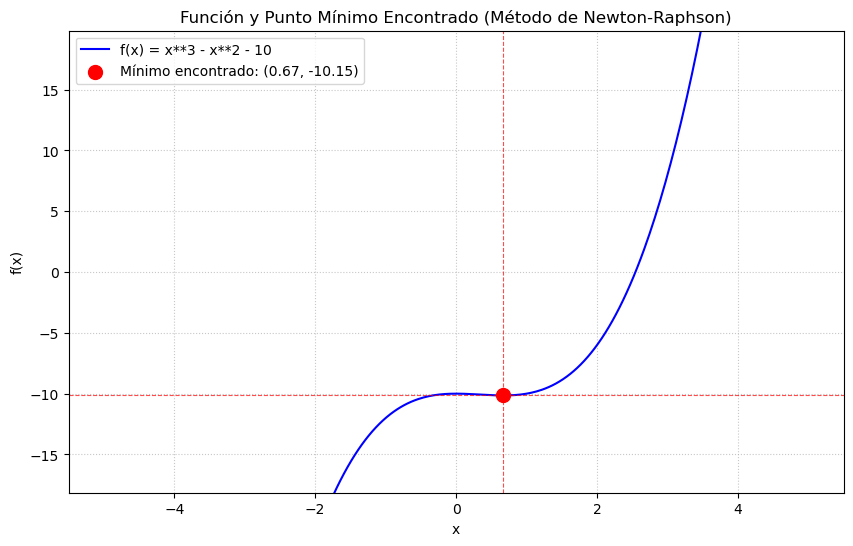

In [8]:
# Generar puntos para graficar la función
x_vals = np.linspace(-5, 5, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = '+str(f_expr), color='blue')
plt.scatter(
    x_min, f_min, color='red', marker='o', s=100,
    label=f'Mínimo encontrado: ({x_min:.2f}, {f_min:.2f})', zorder=5
)
plt.axvline(x=x_min, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=f_min, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(f_min - 8, f_min + 30)
plt.title('Función y Punto Mínimo Encontrado (Método de Newton-Raphson)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

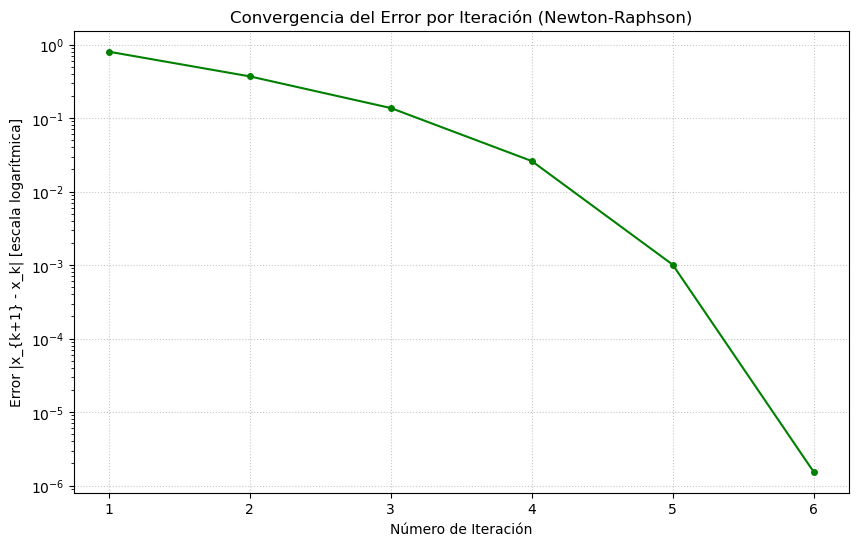

Historial de Error (todas las iteraciones):
   Iteración     Error
0          1  0.800000
1          2  0.369231
2          3  0.137034
3          4  0.026052
4          5  0.001015
5          6  0.000002


In [10]:
# Extraer iteraciones y error de aproximación
iteraciones = [item[0] for item in historial]
errores = [item[1] for item in historial]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones, errores, marker='o', linestyle='-', color='green', markersize=4)
plt.yscale('log')
plt.title('Convergencia del Error por Iteración (Newton-Raphson)')
plt.xlabel('Número de Iteración')
plt.ylabel('Error |x_{k+1} - x_k| [escala logarítmica]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

df_error = pd.DataFrame(historial, columns=['Iteración', 'Error'])
print("Historial de Error (todas las iteraciones):")
print(df_error)

## Newton-Raphson para encontrar raíces

Además de optimización, Newton-Raphson también se usa para resolver ecuaciones de la forma `g(x)=0`.

La iteración para búsqueda de raíces es:

`x_{k+1} = x_k - g(x_k)/g'(x_k)`

A continuación se muestra una implementación general y un ejemplo.

In [11]:
def newton_raphson_raiz(g, dg, x0, tol=1e-8, max_iter=100):
    xk = float(x0)
    historial = []

    for i in range(max_iter):
        gx = float(g(xk))
        dgx = float(dg(xk))

        if abs(dgx) < 1e-14:
            raise ValueError("La derivada es cero o muy cercana a cero. Cambia x0.")

        x_next = xk - gx / dgx
        error = abs(x_next - xk)
        historial.append((i + 1, xk, gx, error))

        xk = x_next

        if error < tol or abs(gx) < tol:
            break

    return xk, historial


x = sp.symbols('x')
g_expr = x**3 - x**2 - 10
dg_expr = sp.diff(g_expr, x)

g = sp.lambdify(x, g_expr, 'numpy')
dg = sp.lambdify(x, dg_expr, 'numpy')

x0_raiz = 1.5
raiz, historial_raiz = newton_raphson_raiz(g, dg, x0_raiz, tol=1e-10, max_iter=50)

print(f"Ecuación: g(x) = {g_expr}")
print(f"Aproximación de la raíz: x = {raiz:.10f}")
print(f"g(raíz) = {g(raiz):.3e}")
print(f"Iteraciones: {len(historial_raiz)}")

df_raiz = pd.DataFrame(historial_raiz, columns=['Iteración', 'x_k', 'g(x_k)', 'Error'])
print(df_raiz)

Ecuación: g(x) = x**3 - x**2 - 10
Aproximación de la raíz: x = 2.5445115284
g(raíz) = -3.553e-15
Iteraciones: 7
   Iteración       x_k        g(x_k)         Error
0          1  1.500000 -8.875000e+00  2.366667e+00
1          2  3.866667  3.285985e+01  8.852331e-01
2          3  2.981434  7.612857e+00  3.677003e-01
3          4  2.613733  1.024383e+00  6.709637e-02
4          5  2.546637  3.049649e-02  2.123296e-03
5          6  2.544514  2.992572e-05  2.087653e-06
6          7  2.544512  2.891198e-11  2.017053e-12


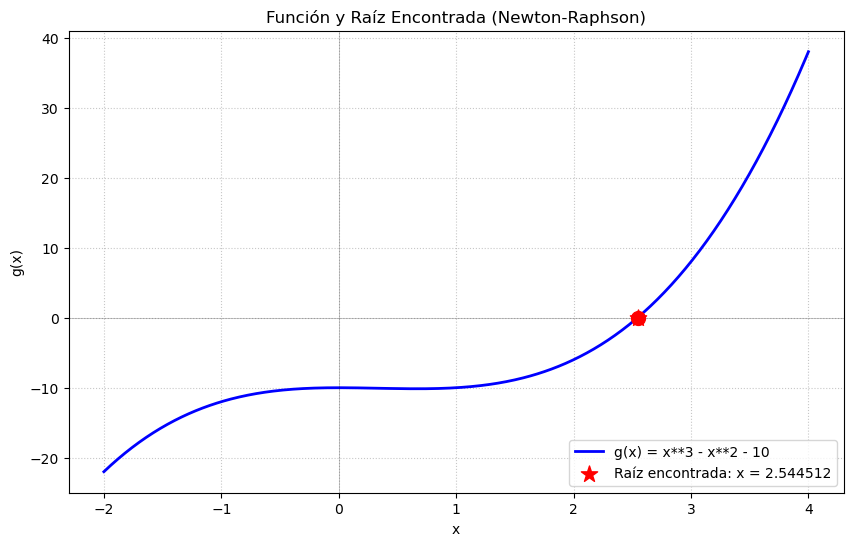

In [12]:
# Gráfica de la función g(x) con la raíz encontrada
x_vals = np.linspace(-2, 4, 500)
y_vals = g(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'g(x) = {g_expr}')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.scatter(raiz, 0, color='red', s=150, marker='*', zorder=5, label=f'Raíz encontrada: x = {raiz:.6f}')
plt.scatter(raiz, g(raiz), color='red', s=100, marker='o', zorder=5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('Función y Raíz Encontrada (Newton-Raphson)')
plt.legend(fontsize=10)
plt.show()

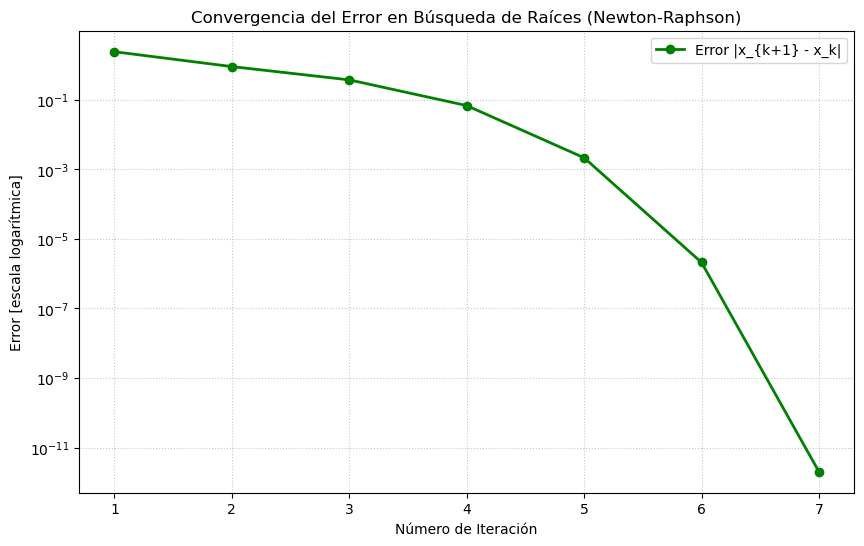

In [13]:
# Gráfica de convergencia del error
iteraciones_raiz = [item[0] for item in historial_raiz]
errores_raiz = [item[3] for item in historial_raiz]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones_raiz, errores_raiz, 'go-', linewidth=2, markersize=6, label='Error |x_{k+1} - x_k|')
plt.yscale('log')
plt.xlabel('Número de Iteración')
plt.ylabel('Error [escala logarítmica]')
plt.title('Convergencia del Error en Búsqueda de Raíces (Newton-Raphson)')
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.legend(fontsize=10)
plt.show()

In [ ]:
# Tabla de iteraciones con formato estandar y legible
columnas = [
    'Iteración', 'x_k', 'y_k', 'f(x_k, y_k)',
    'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente'
]

filas = []

if 'historial' in globals() and historial:
    n_cols = len(historial[0])

    if n_cols == 9:
        for it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad in historial:
            filas.append([it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad])
    elif n_cols == 4:
        for it, xk, gk, err in historial:
            filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])
    elif n_cols == 2:
        for it, err in historial:
            filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

if (not filas) and ('historial_raiz' in globals()) and historial_raiz:
    for it, xk, gk, err in historial_raiz:
        filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])

elif (not filas) and ('historial_error_min' in globals()) and historial_error_min:
    for it, err in historial_error_min:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif (not filas) and ('historial_error' in globals()) and historial_error:
    for it, err in historial_error:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

tabla = pd.DataFrame(filas, columns=columnas)

if tabla.empty:
    print('No se encontraron datos de historial para construir la tabla.')
else:
    tabla_fmt = tabla.copy()
    formato = {
        'x_k': '{:.6f}',
        'y_k': '{:.6f}',
        'f(x_k, y_k)': '{:.6f}',
        'df_dx': '{:.6f}',
        'df_dy': '{:.6f}',
        'h_opt': '{:.6f}',
        'Error_paso': '{:.3e}',
        'Norma_gradiente': '{:.3e}'
    }

    for col, fmt in formato.items():
        tabla_fmt[col] = tabla_fmt[col].map(lambda v: '' if pd.isna(v) else fmt.format(v))

    print('Tabla de iteraciones (valores y error):')
    print(tabla_fmt.to_string(index=False))